In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r'C:\Users\User\Desktop\P\top50.csv')
df.head()

,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [3]:
df.shape

(50, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Track.Name        50 non-null     object
 1   Artist.Name       50 non-null     object
 2   Genre             50 non-null     object
 3   Beats.Per.Minute  50 non-null     int64 
 4   Energy            50 non-null     int64 
 5   Danceability      50 non-null     int64 
 6   Loudness..dB..    50 non-null     int64 
 7   Liveness          50 non-null     int64 
 8   Valence.          50 non-null     int64 
 9   Length.           50 non-null     int64 
 10  Acousticness..    50 non-null     int64 
 11  Speechiness.      50 non-null     int64 
 12  Popularity        50 non-null     int64 
dtypes: int64(10), object(3)
memory usage: 5.2+ KB


In [5]:
df.describe()

,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,120.060000,64.060000,71.38000,-5.660000,14.660000,54.600000,200.960000,22.160000,12.480000,87.500000
std,30.898392,14.231913,11.92988,2.056448,11.118306,22.336024,39.143879,18.995553,11.161596,4.491489
min,85.000000,32.000000,29.00000,-11.000000,5.000000,10.000000,115.000000,1.000000,3.000000,70.000000
25%,96.000000,55.250000,67.00000,-6.750000,8.000000,38.250000,176.750000,8.250000,5.000000,86.000000
50%,104.500000,66.500000,73.50000,-6.000000,11.000000,55.500000,198.000000,15.000000,7.000000,88.000000
75%,137.500000,74.750000,79.75000,-4.000000,15.750000,69.500000,217.500000,33.750000,15.000000,90.750000
max,190.000000,88.000000,90.00000,-2.000000,58.000000,95.000000,309.000000,75.000000,46.000000,95.000000


In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}")

Missing values per column:
Track.Name          0
Artist.Name         0
Genre               0
Beats.Per.Minute    0
Energy              0
Danceability        0
Loudness..dB..      0
Liveness            0
Valence.            0
Length.             0
Acousticness..      0
Speechiness.        0
Popularity          0
dtype: int64


In [7]:
# Step 5: Remove duplicates
df.drop_duplicates(inplace=True)


In [8]:
df.shape

(50, 13)

In [9]:
df.duplicated().sum()

0

In [10]:
#Rename columns for easier access
#df.rename(columns={
#    'Loudness..dB..': 'loudness(dB)',
#    'Valence.': 'Valence',
#    'Length.': 'Length',
#    'Acousticness..': 'Acousticness',
#    'Speechiness.': 'Speechiness',
#}, inplace=True)

df.columns = df.columns.str.strip().str.lower().str.replace(r"\.+","",regex=True).str.replace(" ","_")

In [11]:
df.columns

Index(['trackname', 'artistname', 'genre', 'beatsperminute', 'energy',
       'danceability', 'loudnessdb', 'liveness', 'valence', 'length',
       'acousticness', 'speechiness', 'popularity'],
      dtype='object')

In [12]:
num_cols = df.select_dtypes(include="integer")
num_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
beatsperminute,50.0,120.06,30.898392,85.0,96.00,104.5,137.50,190.0
energy,50.0,64.06,14.231913,32.0,55.25,66.5,74.75,88.0
danceability,50.0,71.38,11.929880,29.0,67.00,73.5,79.75,90.0
loudnessdb,50.0,-5.66,2.056448,-11.0,-6.75,-6.0,-4.00,-2.0
liveness,50.0,14.66,11.118306,5.0,8.00,11.0,15.75,58.0
valence,50.0,54.60,22.336024,10.0,38.25,55.5,69.50,95.0
length,50.0,200.96,39.143879,115.0,176.75,198.0,217.50,309.0
acousticness,50.0,22.16,18.995553,1.0,8.25,15.0,33.75,75.0
speechiness,50.0,12.48,11.161596,3.0,5.00,7.0,15.00,46.0
popularity,50.0,87.50,4.491489,70.0,86.00,88.0,90.75,95.0


In [13]:
#Top 10 most popular songs?
top10Songs = df[["trackname","artistname","popularity","genre"]].sort_values("popularity",ascending=False).head(10)
top10Songs

,trackname,artistname,popularity,genre
9,bad guy,Billie Eilish,95,electropop
4,Goodbyes (Feat. Young Thug),Post Malone,94,dfw rap
10,Callaita,Bad Bunny,93,reggaeton
14,Money In The Grave (Drake ft. Rick Ross),Drake,92,canadian hip hop
1,China,Anuel AA,92,reggaeton flow
6,Ransom,Lil Tecca,92,trap music
36,Otro Trago,Sech,91,panamanian pop
21,Panini,Lil Nas X,91,country rap
20,Piece Of Your Heart,MEDUZA,91,pop house
19,Truth Hurts,Lizzo,91,escape room


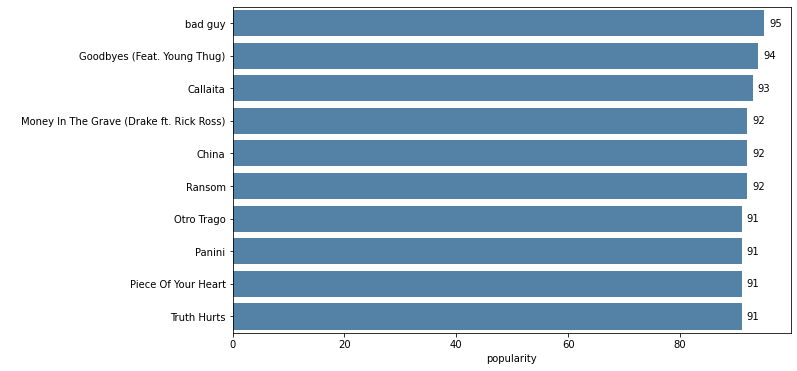

In [14]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=top10Songs,x="popularity",y="trackname",color="steelblue")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)
plt.ylabel(" ")
plt.show()

In [15]:
#Most frequent Artist
MostFreqArtist = df["artistname"].value_counts().head(10)
MostFreqArtist

Ed Sheeran          4
Shawn Mendes        2
Lil Nas X           2
J Balvin            2
Sech                2
Billie Eilish       2
The Chainsmokers    2
Marshmello          2
Post Malone         2
Ariana Grande       2
Name: artistname, dtype: int64

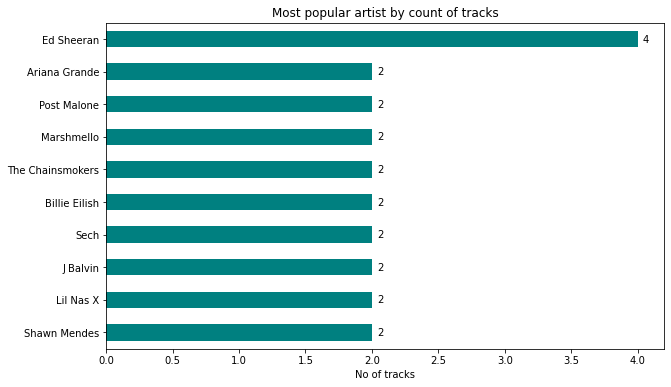

In [16]:
plt.figure(figsize=(10,6))
ax = MostFreqArtist.sort_values().plot(kind="barh",color="teal")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)
plt.title("Most popular artist by count of tracks")
plt.xlabel("No of tracks")

plt.show()

In [17]:
#Most common genre
MostCommonGenre = df["genre"].value_counts().head(10)
MostCommonGenre

dance pop           8
pop                 7
latin               5
canadian hip hop    3
edm                 3
reggaeton           2
reggaeton flow      2
panamanian pop      2
canadian pop        2
electropop          2
Name: genre, dtype: int64

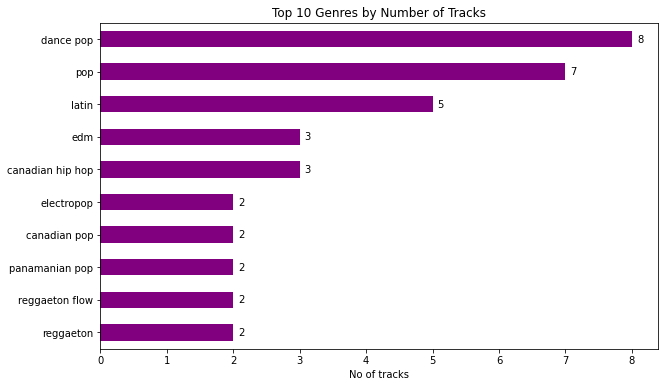

In [18]:
plt.figure(figsize=(10,6))
ax = MostCommonGenre.sort_values().plot(kind="barh",color="purple")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)
plt.title("Top 10 Genres by Number of Tracks")
plt.xlabel("No of tracks")

plt.show()

In [19]:
#Which genres are most popular?
PopularGenre = df.groupby("genre")["popularity"].agg(["mean","median","count"]).sort_values("mean",ascending=False).head(10)
PopularGenre

,mean,median,count
genre,,,
dfw rap,92.500000,92.5,2
trap music,92.000000,92.0,1
electropop,92.000000,92.0,2
reggaeton,91.000000,91.0,2
pop house,91.000000,91.0,1
escape room,91.000000,91.0,1
latin,89.800000,90.0,5
canadian hip hop,89.666667,89.0,3
panamanian pop,89.000000,89.0,2


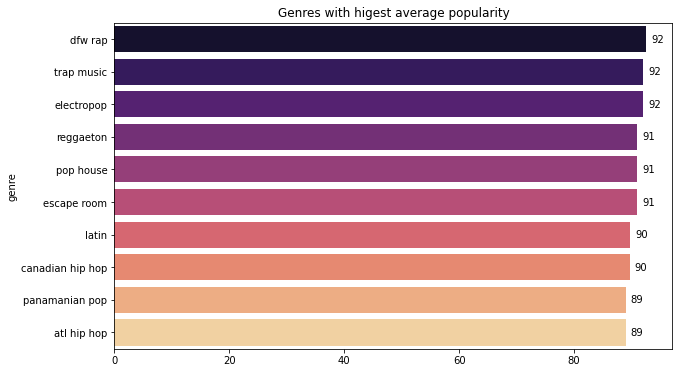

In [20]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x=PopularGenre["mean"],y=PopularGenre.index,palette="magma")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Genres with higest average popularity")
plt.xlabel(" ")
plt.show()

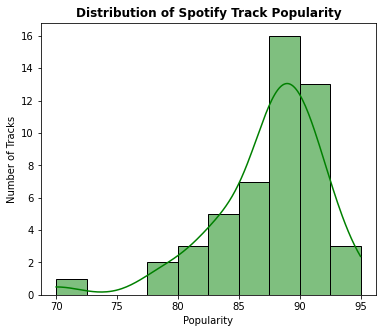

In [21]:
#Distribution of Popularity
plt.figure(figsize=(6, 5))
sns.histplot(df['popularity'], bins=10, kde=True, color='green')
plt.title('Distribution of Spotify Track Popularity',fontweight='bold')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.show()



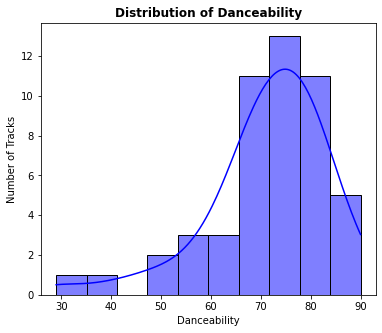

In [22]:
#Danceability Distribution
plt.figure(figsize=(6, 5))
sns.histplot(df['danceability'], bins=10, kde=True, color='blue')
plt.title('Distribution of Danceability',fontweight='bold')
plt.xlabel('Danceability')
plt.ylabel('Number of Tracks')
plt.show()

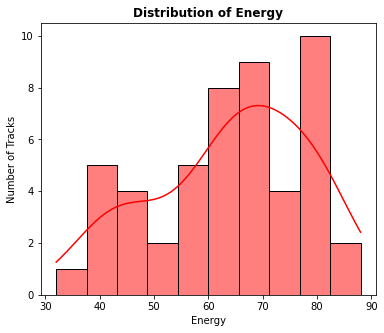

In [23]:
#Energy Distribution
plt.figure(figsize=(6, 5))
sns.histplot(df['energy'], bins=10, kde=True, color='red')
plt.title('Distribution of Energy',fontweight='bold')
plt.xlabel('Energy')
plt.ylabel('Number of Tracks')
plt.show()

In [24]:
#Heatmap
features = df.select_dtypes(include="number")
corr = features.corr()
corr

,beatsperminute,energy,danceability,loudnessdb,liveness,valence,length,acousticness,speechiness,popularity
beatsperminute,1.000000,0.043756,-0.094183,0.017016,-0.167286,-0.011586,-0.139288,-0.031450,0.557052,0.196097
energy,0.043756,1.000000,0.018254,0.670794,0.162768,0.438820,0.224677,-0.339892,-0.089860,-0.080295
danceability,-0.094183,0.018254,1.000000,0.016255,-0.149636,0.172829,-0.000185,-0.098165,-0.103472,-0.071413
loudnessdb,0.017016,0.670794,0.016255,1.000000,0.258652,0.237614,0.219219,-0.138300,-0.272213,-0.043085
liveness,-0.167286,0.162768,-0.149636,0.258652,1.000000,0.016123,0.131782,0.021328,-0.125286,0.092564
valence,-0.011586,0.438820,0.172829,0.237614,0.016123,1.000000,-0.017782,-0.052323,-0.053242,-0.317752
length,-0.139288,0.224677,-0.000185,0.219219,0.131782,-0.017782,1.000000,-0.076293,0.046755,-0.087639
acousticness,-0.031450,-0.339892,-0.098165,-0.138300,0.021328,-0.052323,-0.076293,1.000000,0.008293,-0.034684
speechiness,0.557052,-0.089860,-0.103472,-0.272213,-0.125286,-0.053242,0.046755,0.008293,1.000000,0.238553
popularity,0.196097,-0.080295,-0.071413,-0.043085,0.092564,-0.317752,-0.087639,-0.034684,0.238553,1.000000


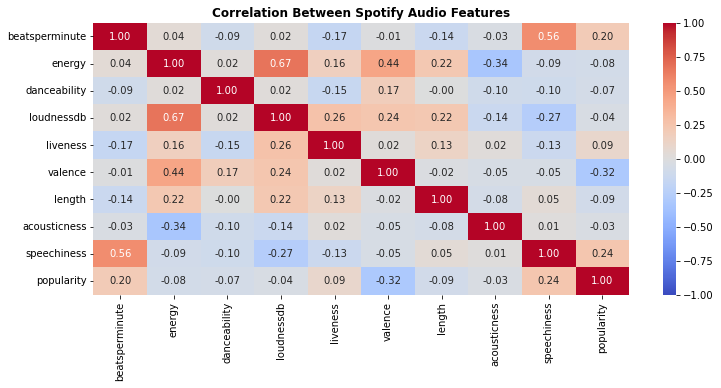

In [25]:
plt.figure(figsize=(12,5))

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,fmt=".2f",vmin=-1,vmax=1)
plt.title('Correlation Between Spotify Audio Features',fontweight='bold')
plt.show()

In [26]:
#What Influences popularity
popularity_corr = corr["popularity"].sort_values(ascending=False)
print(popularity_corr)

popularity        1.000000
speechiness       0.238553
beatsperminute    0.196097
liveness          0.092564
acousticness     -0.034684
loudnessdb       -0.043085
danceability     -0.071413
energy           -0.080295
length           -0.087639
valence          -0.317752
Name: popularity, dtype: float64


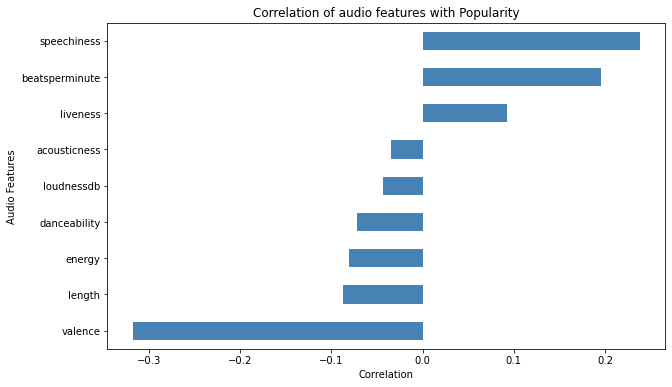

In [27]:
plt.figure(figsize=(10,6))
popularity_corr.drop("popularity").sort_values().plot(kind="barh",color="steelblue")
plt.title("Correlation of audio features with Popularity")
plt.xlabel("Correlation")
plt.ylabel("Audio Features")

plt.show()

Correlation does not establish causation.For example, if beatsperminute & popularity have a positive correlation, it does not 
gurantee that increasing a song's beatsperminute causes it to become popular.

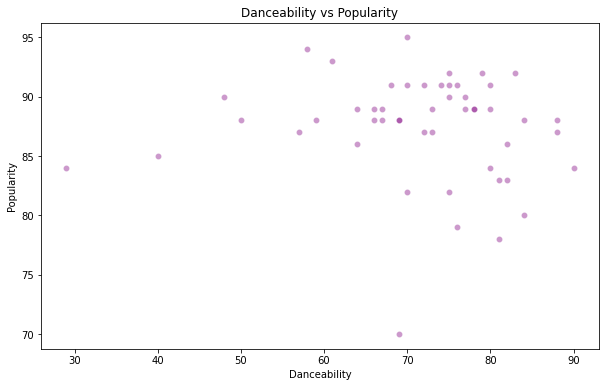

In [28]:
#Danceability vs Popularity
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(min(10000,len(df))),x="danceability",y="popularity",alpha=0.4,color="purple")
plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

In [29]:
#calculate pearson's correlation
corr,p_value = pearsonr(df["danceability"].dropna(),
                       df.loc[df["danceability"].notna(),"popularity"])
print("Correlation: ",corr)
print("P-value: ",p_value)

Correlation:  -0.07141325258733469
P-value:  0.6221356203236242


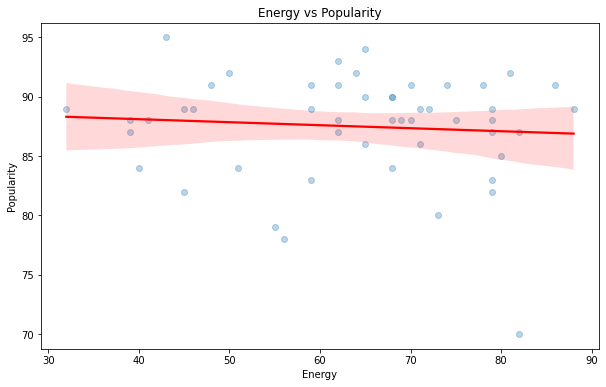

In [30]:
#Energy vs Popularity
plt.figure(figsize=(10,6))
sns.regplot(data=df.sample(min(10000,len(df))),x="energy",y="popularity",scatter_kws={"alpha":0.3},line_kws={"color":"red"})
plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

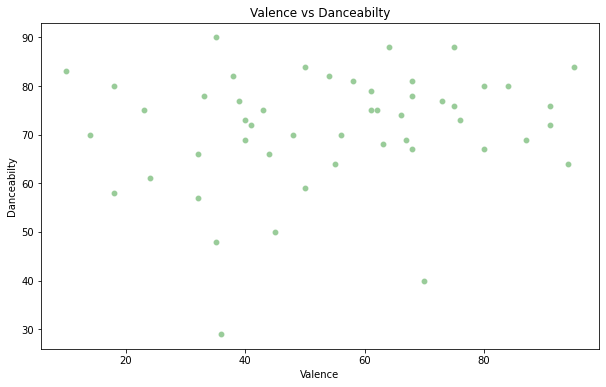

In [31]:
#Valence vs Danceabilty
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(min(10000,len(df))),x="valence",y="danceability",alpha=0.4,color="green")
plt.title("Valence vs Danceabilty")
plt.xlabel("Valence")
plt.ylabel("Danceabilty")
plt.show()

In [32]:
#Audio Features by Genre
genre_features = (df.groupby("genre")[["danceability","energy","valence","acousticness","speechiness","popularity",
                                      "loudnessdb","liveness","beatsperminute","length"]].mean())
genre_features.head()

,danceability,energy,valence,acousticness,speechiness,popularity,loudnessdb,liveness,beatsperminute,length
genre,,,,,,,,,,
atl hip hop,80.0,59.0,18.0,2.0,15.0,89.0,-7.0,13.0,98.0,200.0
australian pop,82.0,59.0,54.0,69.0,10.0,83.0,-6.0,18.0,98.0,210.0
big room,66.0,72.0,32.0,18.0,6.0,89.0,-7.0,14.0,114.0,164.0
boy band,84.0,73.0,95.0,4.0,6.0,80.0,-5.0,11.0,138.0,181.0
brostep,67.5,70.5,55.5,13.0,5.0,88.0,-2.5,37.5,94.0,198.0


In [33]:
#Find genres with highest danceability
genre_features.sort_values("danceability",ascending=False).head(10)

,danceability,energy,valence,acousticness,speechiness,popularity,loudnessdb,liveness,beatsperminute,length
genre,,,,,,,,,,
r&b en espanol,88.0,69.0,75.000000,39.000000,12.000000,88.000000,-4.000000,5.0,98.0,162.0
boy band,84.0,73.0,95.000000,4.000000,6.000000,80.000000,-5.000000,11.0,138.0,181.0
australian pop,82.0,59.0,54.000000,69.000000,10.000000,83.000000,-6.000000,18.0,98.0,210.0
atl hip hop,80.0,59.0,18.000000,2.000000,15.000000,89.000000,-7.000000,13.0,98.0,200.0
reggaeton flow,80.0,80.0,59.500000,11.000000,8.000000,87.500000,-4.000000,8.5,98.5,305.5
canadian hip hop,80.0,45.0,33.333333,21.666667,5.333333,89.666667,-6.333333,15.0,109.0,193.0
country rap,79.0,60.5,56.000000,19.500000,9.000000,89.000000,-6.000000,11.5,145.0,136.0
trap music,75.0,64.0,23.000000,2.000000,29.000000,92.000000,-6.000000,7.0,180.0,131.0
panamanian pop,74.0,74.5,69.000000,10.500000,27.000000,89.000000,-3.500000,8.5,176.0,257.0


In [34]:
#Highest energy
genre_features.sort_values("energy",ascending=False).head(10)

,danceability,energy,valence,acousticness,speechiness,popularity,loudnessdb,liveness,beatsperminute,length
genre,,,,,,,,,,
reggaeton flow,80.0,80.0,59.5,11.0,8.0,87.5,-4.0,8.5,98.5,305.5
latin,72.0,76.6,72.6,17.8,14.6,89.8,-4.2,21.0,126.2,225.2
panamanian pop,74.0,74.5,69.0,10.5,27.0,89.0,-3.5,8.5,176.0,257.0
pop house,68.0,74.0,63.0,4.0,3.0,91.0,-7.0,7.0,124.0,153.0
boy band,84.0,73.0,95.0,4.0,6.0,80.0,-5.0,11.0,138.0,181.0
big room,66.0,72.0,32.0,18.0,6.0,89.0,-7.0,14.0,114.0,164.0
brostep,67.5,70.5,55.5,13.0,5.0,88.0,-2.5,37.5,94.0,198.0
r&b en espanol,88.0,69.0,75.0,39.0,12.0,88.0,-4.0,5.0,98.0,162.0
canadian pop,72.5,68.5,81.0,26.5,4.5,74.5,-5.0,10.5,120.5,191.0


In [35]:
#Highest valence
genre_features.sort_values("valence",ascending=False).head(10)

,danceability,energy,valence,acousticness,speechiness,popularity,loudnessdb,liveness,beatsperminute,length
genre,,,,,,,,,,
boy band,84.000000,73.000000,95.0,4.000000,6.000000,80.000000,-5.000000,11.000000,138.000000,181.000000
canadian pop,72.500000,68.500000,81.0,26.500000,4.500000,74.500000,-5.000000,10.500000,120.500000,191.000000
r&b en espanol,88.000000,69.000000,75.0,39.000000,12.000000,88.000000,-4.000000,5.000000,98.000000,162.000000
latin,72.000000,76.600000,72.6,17.800000,14.600000,89.800000,-4.200000,21.000000,126.200000,225.200000
panamanian pop,74.000000,74.500000,69.0,10.500000,27.000000,89.000000,-3.500000,8.500000,176.000000,257.000000
pop house,68.000000,74.000000,63.0,4.000000,3.000000,91.000000,-7.000000,7.000000,124.000000,153.000000
electropop,68.500000,44.000000,62.0,29.000000,34.000000,92.000000,-11.000000,11.000000,135.000000,194.500000
reggaeton flow,80.000000,80.000000,59.5,11.000000,8.000000,87.500000,-4.000000,8.500000,98.500000,305.500000
pop,68.428571,63.285714,58.0,21.428571,9.285714,85.857143,-6.285714,12.142857,114.142857,195.428571


In [36]:
#Compare selected genres
selected_genres = ["pop","latin","boy band","r&b en espanol","jazz"]
genre_comparison = (df[df["genre"].isin(selected_genres)].groupby("genre")[["danceability","energy","valence","acousticness","speechiness",
                                        "popularity","loudnessdb","liveness","beatsperminute","length"]].mean())

genre_comparison

,danceability,energy,valence,acousticness,speechiness,popularity,loudnessdb,liveness,beatsperminute,length
genre,,,,,,,,,,
boy band,84.000000,73.000000,95.0,4.000000,6.000000,80.000000,-5.000000,11.000000,138.000000,181.000000
latin,72.000000,76.600000,72.6,17.800000,14.600000,89.800000,-4.200000,21.000000,126.200000,225.200000
pop,68.428571,63.285714,58.0,21.428571,9.285714,85.857143,-6.285714,12.142857,114.142857,195.428571
r&b en espanol,88.000000,69.000000,75.0,39.000000,12.000000,88.000000,-4.000000,5.000000,98.000000,162.000000


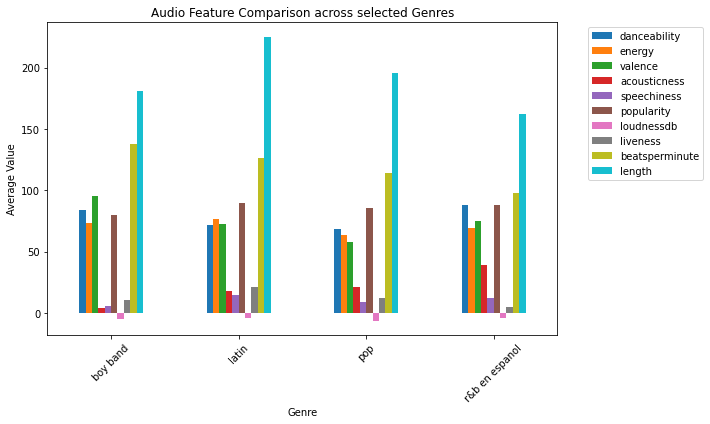

In [37]:
genre_comparison.plot(kind="bar",figsize=(10,6))
plt.title("Audio Feature Comparison across selected Genres")
plt.xlabel("Genre")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.tight_layout()
plt.show()

In [38]:
#Most Popular song by genre
top_by_genre = df.sort_values("popularity",ascending=False).groupby("trackname").head(1)

top_by_genre[["genre","trackname","artistname","popularity"]].head(10)

,genre,trackname,artistname,popularity
9,electropop,bad guy,Billie Eilish,95
4,dfw rap,Goodbyes (Feat. Young Thug),Post Malone,94
10,reggaeton,Callaita,Bad Bunny,93
14,canadian hip hop,Money In The Grave (Drake ft. Rick Ross),Drake,92
1,reggaeton flow,China,Anuel AA,92
6,trap music,Ransom,Lil Tecca,92
36,panamanian pop,Otro Trago,Sech,91
21,country rap,Panini,Lil Nas X,91
20,pop house,Piece Of Your Heart,MEDUZA,91
19,escape room,Truth Hurts,Lizzo,91


In [39]:
#Create popularity Categories
df["popularity_category"] = pd.cut(df["popularity"],bins=[-1,25,50,75,100],labels=["Low","Medium","High","Very High"])
df["popularity_category"].value_counts()

Very High    49
High          1
Low           0
Medium        0
Name: popularity_category, dtype: int64

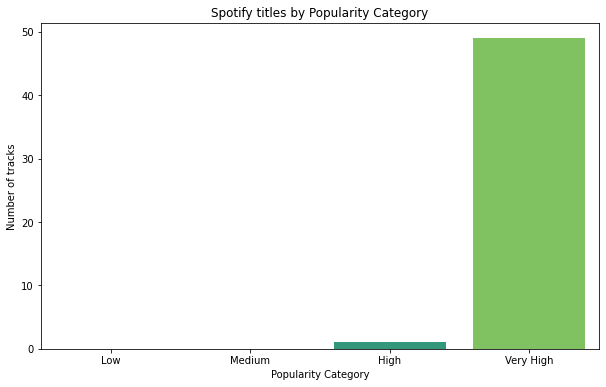

In [40]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="popularity_category",order=["Low","Medium","High","Very High"],palette="viridis")
plt.title("Spotify titles by Popularity Category")
plt.xlabel("Popularity Category")
plt.ylabel("Number of tracks")

plt.show()

In [41]:
#Find songs with a specific profile
dance_songs = df[(df["danceability"]>0.8) & (df["energy"]>0.8) & (df["popularity"] >70)]
dance_songs[["trackname","artistname","genre","popularity","danceability","energy"]].sort_values("popularity",ascending=False).head(20)

,trackname,artistname,genre,popularity,danceability,energy
9,bad guy,Billie Eilish,electropop,95,70,43
4,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,94,58,65
10,Callaita,Bad Bunny,reggaeton,93,61,62
1,China,Anuel AA,reggaeton flow,92,79,81
6,Ransom,Lil Tecca,trap music,92,75,64
14,Money In The Grave (Drake ft. Rick Ross),Drake,canadian hip hop,92,83,50
17,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,dfw rap,91,76,48
21,Panini,Lil Nas X,country rap,91,70,59
28,Con Calma,Daddy Yankee,latin,91,74,86
36,Otro Trago,Sech,panamanian pop,91,75,70


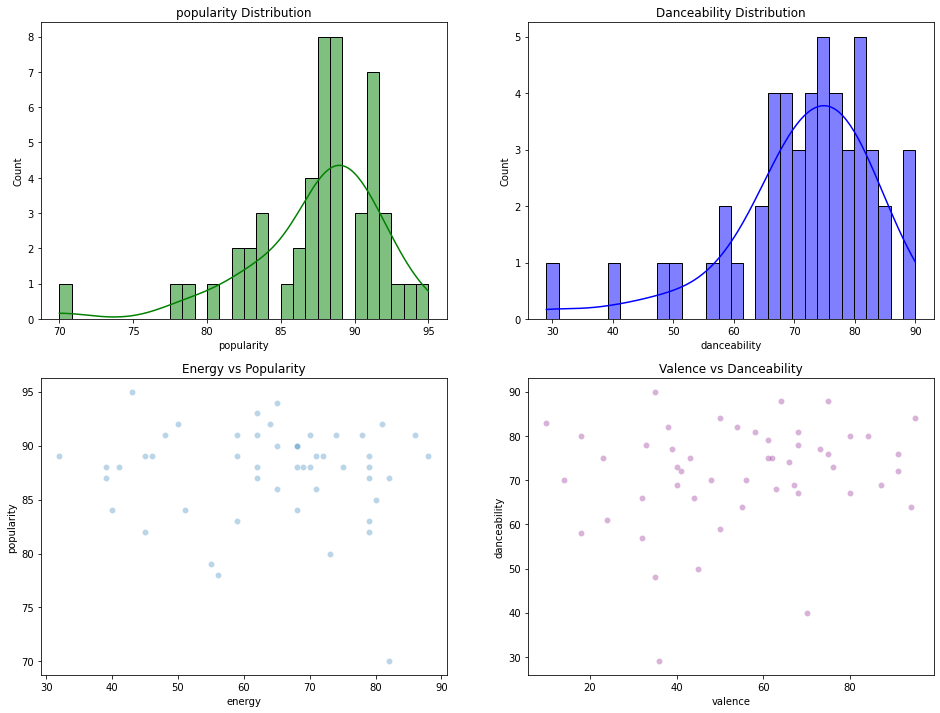

In [42]:
#Summary DashBoard
fig, axes = plt.subplots(2,2,figsize=(16,12))
#Popularity
sns.histplot(df["popularity"],bins=30,kde=True,ax=axes[0,0],color="green")
axes[0,0].set_title("popularity Distribution")
#Danceability
sns.histplot(df["danceability"],bins=30,kde=True,ax=axes[0,1],color="blue")
axes[0,1].set_title("Danceability Distribution")
#Energy vs Popularity
sns.scatterplot(data=df.sample(min(5000,len(df))),x="energy",y="popularity",alpha=0.3,ax=axes[1,0])
axes[1,0].set_title("Energy vs Popularity")
#Valence vs Danceability
sns.scatterplot(data=df.sample(min(5000,len(df))),x="valence",y="danceability",alpha=0.3,color="purple",ax=axes[1,1])
axes[1,1].set_title("Valence vs Danceability")

plt.tight_layout
plt.show()

In [43]:
#Analysis Summary
print("="*60)
print("DATA ANALYSIS SUMMARY\n")
print("="*60)

print(f"Total tracks : {len(df):,}")
print(f"Unique artists : {df['artistname'].nunique():,}")
print(f"Unique genres : {df['genre'].nunique():,}")

print(f"\nAverage Popularity: "
     f"{df['popularity'].mean():.2f}")


print(f"\nAverage danceability: "
     f"{df['danceability'].mean():.2f}")


print(f"\nAverage valence: "
     f"{df['valence'].mean():.2f}")


print(f"\nMost Common Genre: "
     f"{df['genre'].mode()[0]}")


print(f"\nMost Popular Track: "
     f"{df.loc[df['popularity'].idxmax(),'trackname']}")


print(f"Most popular artist for the single highest-popularity track: "
     f"{df.loc[df['popularity'].idxmax(),'artistname']}")

print("="*60)

DATA ANALYSIS SUMMARY

Total tracks : 50
Unique artists : 38
Unique genres : 21

Average Popularity: 87.50

Average danceability: 71.38

Average valence: 54.60

Most Common Genre: dance pop

Most Popular Track: bad guy
Most popular artist for the single highest-popularity track: Billie Eilish


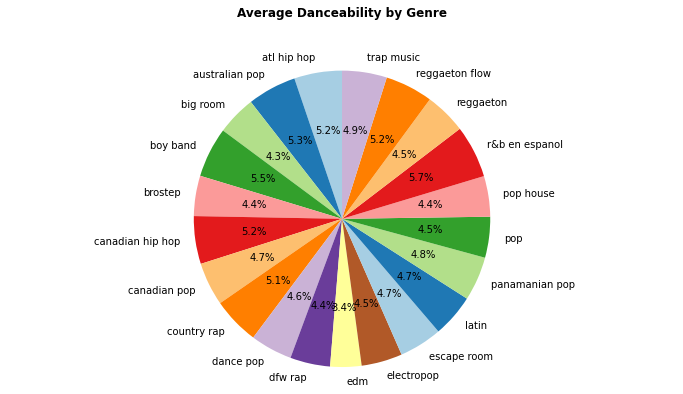

In [44]:
# Plot a pie chart for average danceability by genre
plt.figure(figsize=(12, 6))
avg_danceability_by_genre = df.groupby('genre')['danceability'].mean().reset_index()


plt.pie(avg_danceability_by_genre['danceability'], 
        labels=avg_danceability_by_genre['genre'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=plt.cm.Paired.colors)

# Add title and display the pie chart
plt.title('Average Danceability by Genre', y=1.10,fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [45]:
df.dtypes

trackname                object
artistname               object
genre                    object
beatsperminute            int64
energy                    int64
danceability              int64
loudnessdb                int64
liveness                  int64
valence                   int64
length                    int64
acousticness              int64
speechiness               int64
popularity                int64
popularity_category    category
dtype: object

In [46]:
df['genre'].value_counts()

dance pop           8
pop                 7
latin               5
canadian hip hop    3
edm                 3
reggaeton           2
reggaeton flow      2
panamanian pop      2
canadian pop        2
electropop          2
country rap         2
dfw rap             2
brostep             2
trap music          1
escape room         1
pop house           1
australian pop      1
atl hip hop         1
big room            1
boy band            1
r&b en espanol      1
Name: genre, dtype: int64

In [47]:
def clean_genre(g):
    g=g.lower()
    
    if "pop" in g:
        return "pop"
    elif "hip hop" in g or "rap" in g or "trap" in g:
        return "hiphop"
    #elif "edm" in g or "electro" in g or "house" in g or "bu room" in g:
        #return "edm"
    elif "reggaeton" in g or "latin" in g:
        return "latin"
    elif "country" in g:
        return "country"
    else:
        return "other"
    
    
df["genre_cleaned"] = df["genre"].apply(clean_genre)

In [48]:
df.head()

,trackname,artistname,genre,beatsperminute,energy,danceability,loudnessdb,liveness,valence,length,acousticness,speechiness,popularity,popularity_category,genre_cleaned
0,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79,Very High,pop
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92,Very High,latin
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85,Very High,pop
3,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86,Very High,pop
4,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94,Very High,hiphop


In [49]:
df["genre_cleaned"].value_counts()

pop       23
latin      9
hiphop     9
other      9
Name: genre_cleaned, dtype: int64

In [50]:
#Features & Tarets
features = ['beatsperminute','energy','danceability','loudnessdb','liveness','valence','length','acousticness','speechiness','popularity']

In [51]:
#Remoe "Other"
df =df[df["genre_cleaned"] != "other"]
df

,trackname,artistname,genre,beatsperminute,energy,danceability,loudnessdb,liveness,valence,length,acousticness,speechiness,popularity,popularity_category,genre_cleaned
0,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79,Very High,pop
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92,Very High,latin
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85,Very High,pop
3,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86,Very High,pop
4,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94,Very High,hiphop
5,I Don't Care (with Justin Bieber),Ed Sheeran,pop,102,68,80,-5,9,84,220,9,4,84,Very High,pop
6,Ransom,Lil Tecca,trap music,180,64,75,-6,7,23,131,2,29,92,Very High,hiphop
7,How Do You Sleep?,Sam Smith,pop,111,68,48,-5,8,35,202,15,9,90,Very High,pop
8,Old Town Road - Remix,Lil Nas X,country rap,136,62,88,-6,11,64,157,5,10,87,Very High,hiphop
9,bad guy,Billie Eilish,electropop,135,43,70,-11,10,56,194,33,38,95,Very High,pop


In [52]:
X = df[features]
y=df["genre_cleaned"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [54]:
model = RandomForestClassifier(n_estimators=200,max_depth=None,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [55]:
y_pred = model.predict(X_test)

In [56]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred,zero_division=0)

print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')

Accuracy: 0.8888888888888888
Confusion Matrix:
[[2 0 0]
 [0 1 1]
 [0 0 5]]
Classification Report:
              precision    recall  f1-score   support

      hiphop       1.00      1.00      1.00         2
       latin       1.00      0.50      0.67         2
         pop       0.83      1.00      0.91         5

    accuracy                           0.89         9
   macro avg       0.94      0.83      0.86         9
weighted avg       0.91      0.89      0.88         9



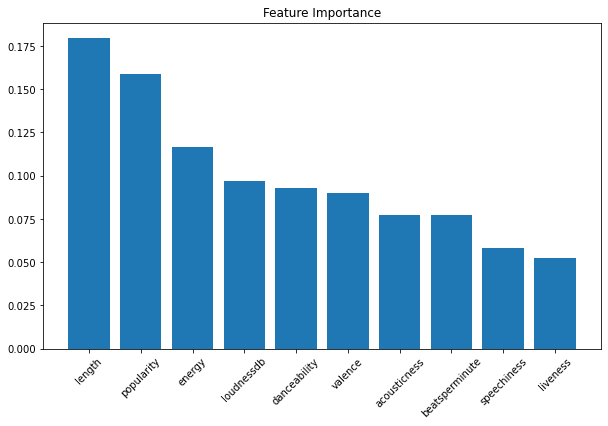

In [57]:
#Feature Importance
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(len(importances)),importances[indices])
plt.xticks(range(len(importances)),[features[i] for i in indices], rotation = 45)
plt.show()